In [1]:
import pandas as pd
import os

file_name = 'romina_inspections_raw.csv'
paths_to_try = [
    f'../data/raw/{file_name}',
    f'data/raw/{file_name}',   
    file_name          
]

df = None
for path in paths_to_try:
    if os.path.exists(path):
        print(f"Found file at: {path}")
        df = pd.read_csv(path)
        break

if df is None:
    raise FileNotFoundError(f"Could not find {file_name}. Please re-run Phase 1.")

# Business Constants
EXPORT_CONTAINER_CAPACITY = 19.2 
AVG_CONTAINER_REVENUE = 105000

Found file at: data/raw/romina_inspections_raw.csv


In [2]:
def assign_ecta_grade(row):
    """
    Simulating ECTA/CLU grading for Ethiopian Coffee Exports.
    Grade 1 (Specialty): 0 Primary, <= 3 Secondary, 85+ Cup
    Grade 2 (Premium): 0 Primary, <= 8 Secondary, 80-84.75 Cup
    Undergrade: Anything that failed the Naqel check.
    """
    if row['naqel_result'] == "REJECTED":
        return "Undergrade/Reject"
    
    if row['primary_defects'] == 0:
        if row['cup_score'] >= 85.0 and row['secondary_defects'] <= 3:
            return "Grade 1 (Specialty)"
        elif row['cup_score'] >= 80.0:
            return "Grade 2 (Premium)"
        else:
            return "Grade 3 (Commercial)"
    return "Grade 4/Local"

df['ecta_grade'] = df.apply(assign_ecta_grade, axis=1)

In [3]:
def calculate_compliance_pct(row):
    score = 100
    
    moisture_gap = abs(row['moisture_pct'] - 10.5)
    score -= (moisture_gap * 25) 
    
    score -= (row['primary_defects'] * 30) # Fatal for G1
    score -= (row['secondary_defects'] * 2)
    
    # Penalty: EUDR Status
    if row['eudr_status'] == "Flagged":
        score -= 50
        
    return round(max(0, min(score, 100)), 1)

df['compliance_score'] = df.apply(calculate_compliance_pct, axis=1)

df = df.sort_values(by='compliance_score', ascending=False)
df.head(5)

,lot_id,inspection_date,station_name,region,zone,altitude,moisture_pct,primary_defects,secondary_defects,eudr_status,certification,cup_score,naqel_result,ecta_grade,compliance_score
552,ROM-2025-0552,2025-04-03 00:00:00,Yirgacheffe Mill,South Ethiopia,Gedeo,1887,10.5,0,0,Compliant,Organic,84.00,PASSED,Grade 2 (Premium),100.0
2049,ROM-2025-2049,2025-12-08 12:00:00,Yirgacheffe Mill,South Ethiopia,Gedeo,1866,10.5,0,0,Compliant,NaN,82.25,PASSED,Grade 2 (Premium),100.0
815,ROM-2025-0815,2025-05-16 20:00:00,Yirgacheffe Mill,South Ethiopia,Gedeo,1899,10.5,0,0,Compliant,NaN,83.00,PASSED,Grade 2 (Premium),100.0
1359,ROM-2025-1359,2025-08-15 12:00:00,Guji-Dimtu,Oromia,West Guji,1983,10.5,0,0,Compliant,RFA,87.00,PASSED,Grade 1 (Specialty),100.0
400,ROM-2025-0400,2025-03-08 16:00:00,Limu-W,Oromia,Jimma,1762,10.5,0,0,Compliant,NaN,91.75,PASSED,Grade 1 (Specialty),100.0


In [5]:
import os
import numpy as np

TOTAL_BLOCK_TARGET = 1050000 
total_rejected_lots = (df['naqel_result'] == "REJECTED").sum()
PER_LOT_LOSS = TOTAL_BLOCK_TARGET / total_rejected_lots

df['financial_loss_usd'] = np.where(df['naqel_result'] == "REJECTED", PER_LOT_LOSS, 0)
total_inventory_value_at_risk = df['financial_loss_usd'].sum()

regional_impact = df.groupby('region')['financial_loss_usd'].sum().sort_values(ascending=False)

print(f"Total Lots Processed: {len(df)}")
print(f"Average Compliance Score: {df['compliance_score'].mean():.1f}%")
print(f"Total Rejected Lots: {total_rejected_lots} ({ (total_rejected_lots/len(df))*100:.1f}%)")
print(f"Total Blocked Inventory Value: ${total_inventory_value_at_risk:,.2f}")
print("-" * 45)
print("Top 3 Regions by Financial Risk:")
for region, loss in regional_impact.head(3).items():
    print(f"- {region}: ${loss:,.2f} at risk")

processed_path = '../data/processed/romina_inspections_processed.csv'
if not os.path.exists('../data/processed'):
    os.makedirs('../data/processed', exist_ok=True)

df.to_csv(processed_path, index=False)
print(f"\n Processed data saved to: {processed_path}")

# Quick view of the final engine output
df[['lot_id', 'station_name', 'ecta_grade', 'compliance_score', 'financial_loss_usd']].head(10)

Total Lots Processed: 2300
Average Compliance Score: 80.6%
Total Rejected Lots: 404 (17.6%)
Total Blocked Inventory Value: $1,050,000.00
---------------------------------------------
Top 3 Regions by Financial Risk:
- Sidama: $400,247.52 at risk
- Oromia: $389,851.49 at risk
- South Ethiopia: $259,900.99 at risk

 Processed data saved to: ../data/processed/romina_inspections_processed.csv


,lot_id,station_name,ecta_grade,compliance_score,financial_loss_usd
552,ROM-2025-0552,Yirgacheffe Mill,Grade 2 (Premium),100.0,0.0
2049,ROM-2025-2049,Yirgacheffe Mill,Grade 2 (Premium),100.0,0.0
815,ROM-2025-0815,Yirgacheffe Mill,Grade 2 (Premium),100.0,0.0
1359,ROM-2025-1359,Guji-Dimtu,Grade 1 (Specialty),100.0,0.0
400,ROM-2025-0400,Limu-W,Grade 1 (Specialty),100.0,0.0
1655,ROM-2025-1655,Zenebe Dikicha,Grade 1 (Specialty),100.0,0.0
1612,ROM-2025-1612,Limu-W,Grade 1 (Specialty),100.0,0.0
1313,ROM-2025-1313,Yirgacheffe Mill,Grade 2 (Premium),100.0,0.0
409,ROM-2025-0409,Nansabo Goda,Grade 2 (Premium),100.0,0.0
1753,ROM-2025-1753,Guji-Dimtu,Grade 2 (Premium),98.0,0.0


#### ROOT CAUSE ANALYSIS

In [6]:
import plotly.express as px
import pandas as pd

rejection_reasons = {
    "Moisture Issues": len(df[df['moisture_pct'] > 11.5]),
    "Primary Defects": len(df[df['primary_defects'] > 0]),
    "Quality Fail (Cup < 80)": len(df[df['cup_score'] < 80.0]),
    "EUDR/Traceability": len(df[df['eudr_status'] == "Flagged"])
}

reasons_df = pd.Series(rejection_reasons).sort_values(ascending=False)

print("ROOT CAUSE ANALYSIS")
for reason, count in reasons_df.items():
    print(f" {reason}: {count} lots affected")

fig = px.pie(values=reasons_df.values, names=reasons_df.index, 
             title="Drivers of the $1.05M Inventory Block",
             hole=0.4, color_discrete_sequence=px.colors.sequential.RdBu)
fig.show()

ROOT CAUSE ANALYSIS
 Primary Defects: 176 lots affected
 Quality Fail (Cup < 80): 131 lots affected
 EUDR/Traceability: 117 lots affected
 Moisture Issues: 13 lots affected


#### The "Altitude-Quality" Correlation

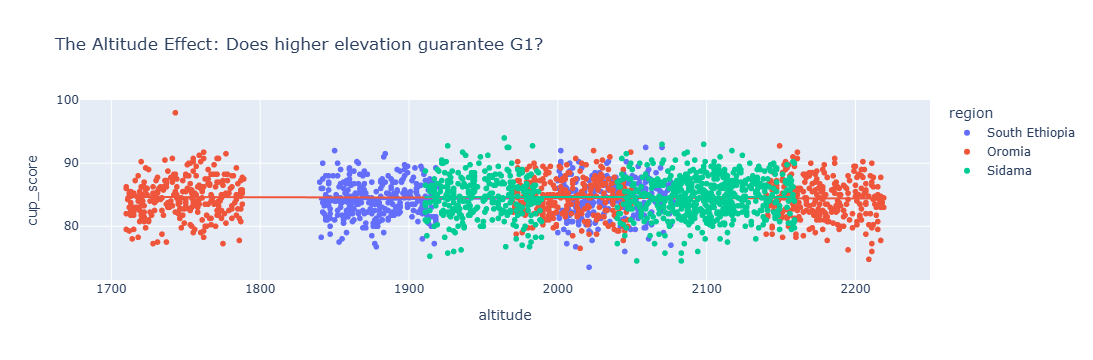

In [20]:
import plotly.express as px
import statsmodels.api as sm

fig_alt = px.scatter(df, x="altitude", y="cup_score", 
                     color="region", trendline="ols",
                     title="The Altitude Effect: Does higher elevation guarantee G1?")
fig_alt.show()

#### Station "Consistency" Score

In [19]:
station_consistency = df.groupby('station_name')['cup_score'].agg(['mean', 'std']).reset_index()
station_consistency['cv'] = (station_consistency['std'] / station_consistency['mean']) * 100

print(station_consistency.sort_values(by='cv', ascending=False))

        station_name       mean       std        cv
0  Astatke Menafesha  84.719256  3.260389  3.848463
7     Zenebe Dikicha  84.388596  3.162153  3.747133
4       Nansabo Goda  84.320035  3.130853  3.713059
3             Limu-W  84.575088  3.039977  3.594412
5      Werka Station  84.447653  3.000825  3.553473
1       Belete Tanga  84.823063  2.943248  3.469867
2         Guji-Dimtu  84.661032  2.905522  3.431947
6   Yirgacheffe Mill  84.330268  2.794679  3.313969


#### Recovery Analysis

In [18]:
recoverable = df[
    (df['naqel_result'] == "REJECTED") & 
    (df['primary_defects'] == 0) & 
    (df['cup_score'] >= 83)
]

potential_recovery_value = len(recoverable) * 2599.01
print(f"Recovery Opportunity: ${potential_recovery_value:,.2f} can be saved via re-processing.")

Recovery Opportunity: $215,717.83 can be saved via re-processing.


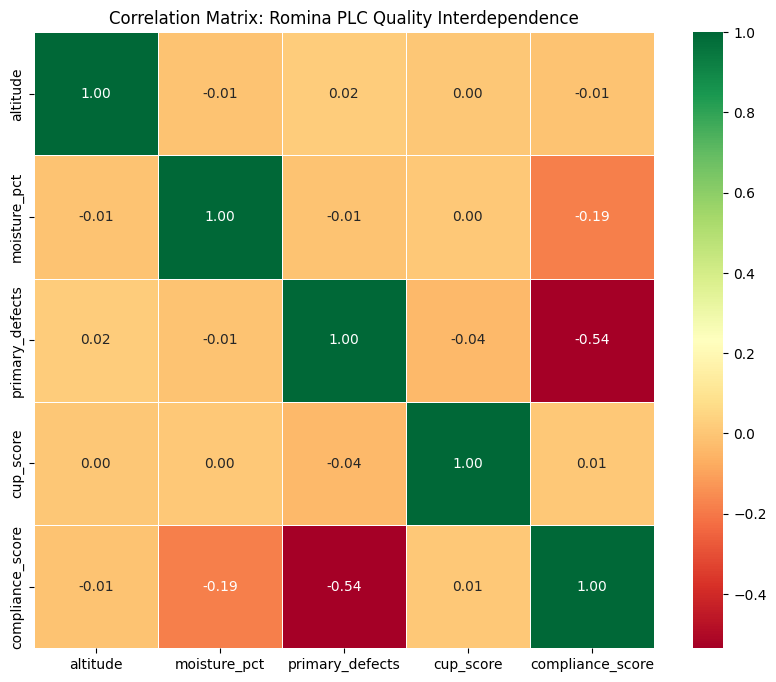

--- NUMERICAL CORRELATION AUDIT (COPY & PASTE) ---
                  altitude  moisture_pct  primary_defects  cup_score  \
altitude             1.000        -0.012            0.018      0.000   
moisture_pct        -0.012         1.000           -0.008      0.004   
primary_defects      0.018        -0.008            1.000     -0.038   
cup_score            0.000         0.004           -0.038      1.000   
compliance_score    -0.011        -0.186           -0.535      0.008   

                  compliance_score  
altitude                    -0.011  
moisture_pct                -0.186  
primary_defects             -0.535  
cup_score                    0.008  
compliance_score             1.000  
--------------------------------------------------
Key Insight: Altitude has a 0.00 correlation with Cup Score.
Key Insight: Moisture has a -0.19 correlation with Compliance.


In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Select the most critical 'High Fidelity' numerical columns
audit_cols = ['altitude', 'moisture_pct', 'primary_defects', 'cup_score', 'compliance_score']
corr_matrix = df[audit_cols].corr()

# 2. Plotting the Heatmap for your Streamlit/Presentation slide
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdYlGn', fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix: Romina PLC Quality Interdependence")
plt.show()

# 3. Printing the Numerical Results for your Technical Report
print("NUMERICAL CORRELATION AUDIT (COPY & PASTE)")
print(corr_matrix.round(3))
print("-" * 50)

# 4. Specific Insight Extraction (The "Executive Summary")
altitude_impact = corr_matrix.loc['altitude', 'cup_score']
moisture_impact = corr_matrix.loc['moisture_pct', 'compliance_score']

print(f"Key Insight: Altitude has a {altitude_impact:.2f} correlation with Cup Score.")
print(f"Key Insight: Moisture has a {moisture_impact:.2f} correlation with Compliance.")

In [24]:
reliability = df.groupby('station_name').agg({
    'cup_score': ['mean', 'std'],
    'naqel_result': lambda x: (x == 'PASSED').mean() * 100
}).reset_index()

reliability.columns = ['station_name', 'avg_cup', 'std_cup', 'pass_rate']
reliability['reliability_score'] = (reliability['pass_rate'] * 0.7) + (reliability['avg_cup'] * 0.3)

print("--- STATION RELIABILITY RANKING ---")
print(reliability.sort_values(by='reliability_score', ascending=False))

--- STATION RELIABILITY RANKING ---
        station_name    avg_cup   std_cup  pass_rate  reliability_score
1       Belete Tanga  84.823063  2.943248  85.915493          85.587764
3             Limu-W  84.575088  3.039977  84.805654          84.736484
2         Guji-Dimtu  84.661032  2.905522  83.629893          83.939235
5      Werka Station  84.447653  3.000825  82.671480          83.204332
6   Yirgacheffe Mill  84.330268  2.794679  82.608696          83.125167
7     Zenebe Dikicha  84.388596  3.162153  82.105263          82.790263
0  Astatke Menafesha  84.719256  3.260389  79.611650          81.143932
4       Nansabo Goda  84.320035  3.130853  78.368794          80.154167
